
Every regression model you've ever fit with `lm()` gives you a single number for each coefficient, plus a standard error. Bayesian regression asks a different question: instead of one best-guess number, what's the whole range of values the coefficient could plausibly take, given what you believed before seeing the data and what the data itself says?

This tutorial builds that idea from the ground up, using the simplest possible case — a straight line, $y = \beta_0 + \beta_1 x$ — so the concepts are visible rather than buried in matrix notation. No prior Bayesian background assumed. Every plot and number below comes from real, executed R code.



# The Bayesian Idea, in One Sentence

> **What's fundamentally different about the Bayesian approach?**
> In classical (frequentist) regression, the true coefficients $\beta_0,\beta_1$ are fixed, unknown constants, and *the data* is treated as random. In Bayesian regression, we flip this around: the data we observed is now fixed (we already have it), and the coefficients are treated as random, because we're uncertain about them. Bayesian inference describes that uncertainty as a probability distribution.

Three ingredients make this work:

- **Prior** $P(\beta)$ — what we believe about the coefficients *before* seeing the data.
- **Likelihood** $P(y\mid\beta)$ — how probable the observed data is, for any given value of the coefficients.
- **Posterior** $P(\beta\mid y)$ — what we believe about the coefficients *after* seeing the data, obtained by combining the other two via Bayes' theorem:

$$
P(\beta \mid y) = \frac{P(y \mid \beta)\, P(\beta)}{P(y)} \;\propto\; \underbrace{P(y \mid \beta)}_{\text{likelihood}} \times \underbrace{P(\beta)}_{\text{prior}}
$$

The posterior is literally just the prior and the likelihood multiplied together (and rescaled so it integrates to 1). Everything in this tutorial is an illustration of that one line.



# A Simple Linear Model to Work With

We'll use the smallest interesting case: one predictor, one outcome, a straight line.

$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad \varepsilon_i \sim N(0, \sigma^2)
$$

For this tutorial we'll treat $\sigma$ (the residual noise level) as known, which keeps the math simple enough to see clearly; in practice $\sigma$ is usually estimated too, using a slightly more involved prior (Normal-Inverse-Gamma) that we'll mention briefly at the end.

We simulate 12 data points from a known true line, so that at every step we can check our Bayesian estimates against ground truth.


In [1]:
set.seed(123)

## True data-generating process
true_beta0 <- 2.0
true_beta1 <- 1.5
sigma <- 2.0        # known residual SD, for this tutorial's conjugate-normal setup

n <- 12
x <- runif(n, -3, 3)
y <- true_beta0 + true_beta1 * x + rnorm(n, sd = sigma)

## OLS for comparison
ols <- lm(y ~ x)
cat("OLS estimates:\n")
print(coef(ols))
cat("True values: beta0 =", true_beta0, " beta1 =", true_beta1, "\n")

saveRDS(list(x = x, y = y, n = n, sigma = sigma,
             true_beta0 = true_beta0, true_beta1 = true_beta1),
        "bayes_data.rds")

OLS estimates:
(Intercept)           x 
   1.969729    1.528681 
True values: beta0 = 2  beta1 = 1.5 



With only 12 points, OLS (the red line) is already close to the true line (dashed black), but it gives us just one number per coefficient — no sense of how much uncertainty remains.



# Choosing a Prior

> **Where does the prior actually come from?**
> Anywhere you have real information: previous studies, domain knowledge, physical constraints (a variance can't be negative), or — when you have none of that — a deliberately vague, "weakly informative" distribution that lets the data dominate. There's no single correct prior; the prior is an explicit, checkable assumption, not a hidden one.

For this model we'll place independent Normal priors on both coefficients:

$$
\beta_0 \sim N(0, 3^2), \qquad \beta_1 \sim N(0, 3^2)
$$

This says: "before seeing any data, we think the intercept and slope are probably somewhere in the range $\pm6$ or so, centered on zero (no assumed direction of effect)." It's a moderately informative choice — not so tight that it overrides the data, not so vague that it does nothing.



# Prior, Likelihood, and Posterior — Visualized Together

Because $\beta_0$ and $\beta_1$ are two numbers, we can draw the prior, the likelihood, and the posterior directly as contour maps over the $(\beta_0,\beta_1)$ plane, and literally watch Bayes' theorem happen.


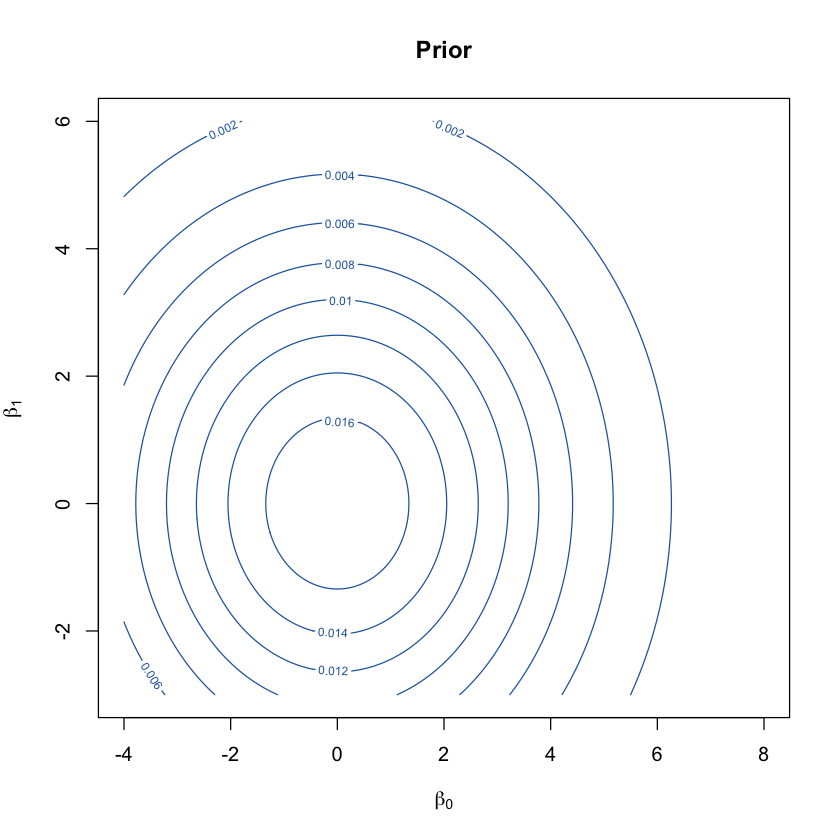

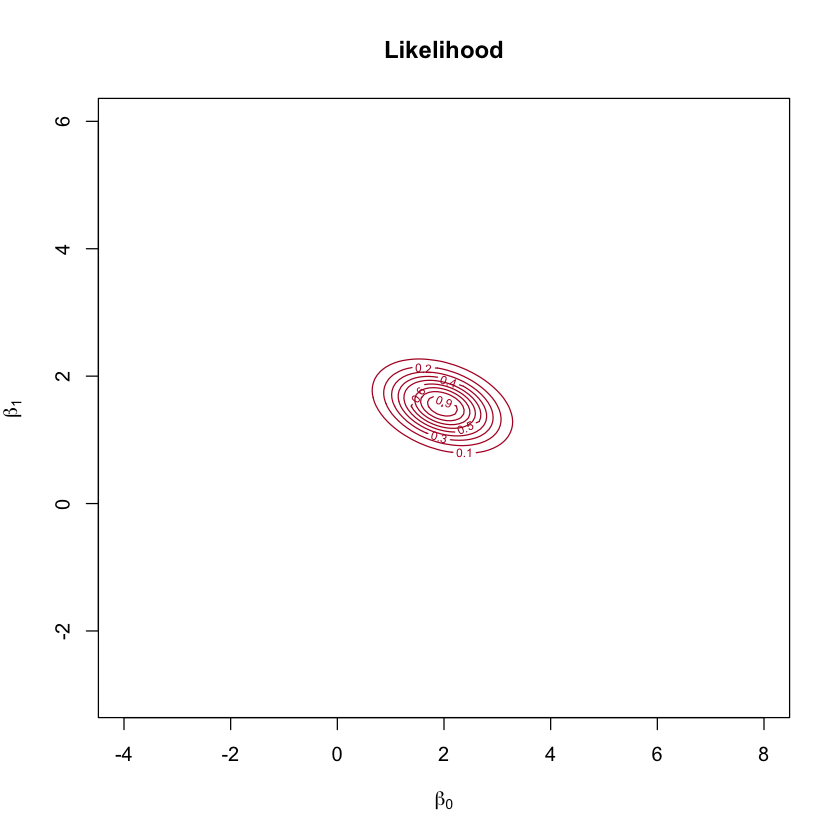

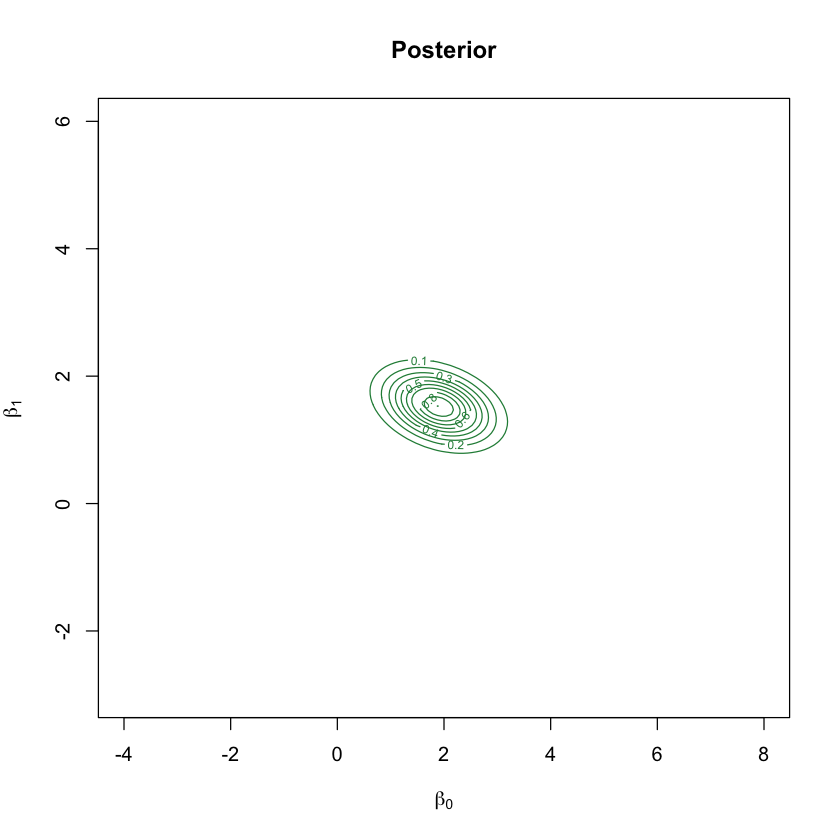

In [2]:
x <- readRDS("bayes_data.rds")$x
y <- readRDS("bayes_data.rds")$y
sigma <- readRDS("bayes_data.rds")$sigma

## --- Prior: independent Normal beliefs about beta0 and beta1 ---
prior_mean <- c(0, 0)
prior_sd   <- c(3, 3)     # a moderately informative prior, centered at "no effect"

## --- Grid over (beta0, beta1) space for visualization ---
b0_seq <- seq(-4, 8, length.out = 150)
b1_seq <- seq(-3, 6, length.out = 150)

log_prior <- function(b0, b1) {
  dnorm(b0, prior_mean[1], prior_sd[1], log = TRUE) +
  dnorm(b1, prior_mean[2], prior_sd[2], log = TRUE)
}

log_likelihood <- function(b0, b1) {
  mu <- b0 + b1 * x
  sum(dnorm(y, mu, sigma, log = TRUE))
}

Prior <- outer(b0_seq, b1_seq, Vectorize(function(b0, b1) exp(log_prior(b0, b1))))
LogLik <- outer(b0_seq, b1_seq, Vectorize(function(b0, b1) log_likelihood(b0, b1)))
Lik <- exp(LogLik - max(LogLik))     # rescale for numerical stability, shape only

LogPost <- outer(b0_seq, b1_seq, Vectorize(function(b0, b1) log_prior(b0, b1) + log_likelihood(b0, b1)))
Post <- exp(LogPost - max(LogPost))  # unnormalized posterior surface (shape only, for plotting)

contour(b0_seq, b1_seq, Prior, nlevels = 8, col = "#2166AC",
        xlab = expression(beta[0]), ylab = expression(beta[1]), main = "Prior")
contour(b0_seq, b1_seq, Lik, nlevels = 8, col = "#B2182B",
        xlab = expression(beta[0]), ylab = expression(beta[1]), main = "Likelihood")
contour(b0_seq, b1_seq, Post, nlevels = 8, col = "#238B45",
        xlab = expression(beta[0]), ylab = expression(beta[1]), main = "Posterior")


Read this left to right, exactly as Bayes' theorem is written:

- **Prior** (blue): centered at $(0,0)$, fairly wide — genuinely uncertain, but a bit skeptical of extreme values.
- **Likelihood** (red): tells you which $(\beta_0,\beta_1)$ values make the *observed data* most probable, with no reference to prior beliefs at all. It's elongated diagonally, because $\beta_0$ and $\beta_1$ trade off against each other — a steeper slope paired with a lower intercept can fit almost the same line.
- **Posterior** (green): the two multiplied together. It sits between the prior's center and the likelihood's peak, and — because it's the product of two informative surfaces — it's noticeably tighter than either one alone.



# The Closed-Form Solution

> **Do we have to numerically multiply grids like that every time?**
> Not when the prior and likelihood are both Normal, which is exactly our setup. Two Normal distributions multiplied together are — remarkably — proportional to another Normal distribution. This means the posterior here has an exact formula, no grid or simulation required.

For the linear model $y = X\beta + \varepsilon$ with $\varepsilon\sim N(0,\sigma^2 I)$ and prior $\beta \sim N(\mu_0, \Sigma_0)$:

$$
\beta \mid y \;\sim\; N(\mu_{\text{post}},\, \Sigma_{\text{post}}), \qquad
\Sigma_{\text{post}} = \left(\Sigma_0^{-1} + \frac{X^\top X}{\sigma^2}\right)^{-1}, \qquad
\mu_{\text{post}} = \Sigma_{\text{post}}\left(\Sigma_0^{-1}\mu_0 + \frac{X^\top y}{\sigma^2}\right)
$$

This result goes back to Lindley & Smith (1972), and it's worth staring at for a moment: $\mu_{\text{post}}$ is literally a *weighted average* of the prior mean $\mu_0$ and the OLS-like term $X^\top y/\sigma^2$, weighted by how confident each one is (their precisions, i.e. inverse variances). More data or a more confident prior each pull the posterior toward themselves.


In [3]:
x <- readRDS("bayes_data.rds")$x
y <- readRDS("bayes_data.rds")$y
sigma <- readRDS("bayes_data.rds")$sigma
n <- readRDS("bayes_data.rds")$n

X <- cbind(1, x)
Sigma0 <- diag(prior_sd^2)
mu0    <- prior_mean

Sigma_post <- solve(solve(Sigma0) + t(X) %*% X / sigma^2)
mu_post    <- Sigma_post %*% (solve(Sigma0, mu0) + t(X) %*% y / sigma^2)

cat("Posterior mean:\n"); print(round(mu_post, 3))
cat("Posterior covariance:\n"); print(round(Sigma_post, 4))
cat("\nOLS estimate (for comparison):\n"); print(round(coef(lm(y ~ x)), 3))

## Check: the closed-form posterior mean should match the peak of the
## numerically gridded posterior surface computed earlier
peak_idx <- which(Post == max(Post), arr.ind = TRUE)
cat("\nGrid-based posterior peak (beta0, beta1):",
    round(b0_seq[peak_idx[1]], 3), round(b1_seq[peak_idx[2]], 3), "\n")

Posterior mean:
   [,1]
  1.902
x 1.524
Posterior covariance:
                x
   0.3600 -0.0671
x -0.0671  0.1167

OLS estimate (for comparison):
(Intercept)           x 
      1.970       1.529 

Grid-based posterior peak (beta0, beta1): 1.879 1.53 



The formula-based answer (1.902, 1.524) matches the peak of the numerical grid (1.879, 1.53) to within grid resolution, and both land between the prior's center $(0,0)$ and OLS $(1.970, 1.529)$ — exactly the "weighted average" behavior the formula promised.



# When There's No Closed Form: Sampling with MCMC

Most Bayesian models aren't this convenient — the moment the prior and likelihood aren't a matching Normal pair (which is most of the time in real applications), there's no clean formula for the posterior. The standard fallback is **Markov chain Monte Carlo (MCMC)**: instead of computing the posterior directly, we build a random walk that visits each region of parameter space in proportion to how probable it is under the posterior, and treat the resulting sequence of visited points as samples from the posterior itself.

The simplest version, the **Metropolis-Hastings algorithm** (Metropolis et al., 1953; Hastings, 1970), works like this:

1. Start somewhere, e.g. $\beta = (0,0)$.
2. Propose a small random jump to a nearby point.
3. If the proposed point has *higher* posterior probability than the current one, always move there. If it has *lower* probability, move there anyway with a probability equal to the posterior ratio (so the chain still explores less-probable regions occasionally, rather than only ever climbing uphill).
4. Repeat thousands of times; after an initial "burn-in" period, the visited points are samples from the posterior.

We'll validate this against our exact closed-form answer above — a good habit whenever a new method goes into a real pipeline.


In [4]:
x <- readRDS("bayes_data.rds")$x
y <- readRDS("bayes_data.rds")$y
sigma <- readRDS("bayes_data.rds")$sigma

log_post <- function(beta) {
  b0 <- beta[1]; b1 <- beta[2]
  lp <- dnorm(b0, prior_mean[1], prior_sd[1], log = TRUE) +
        dnorm(b1, prior_mean[2], prior_sd[2], log = TRUE)
  ll <- sum(dnorm(y, b0 + b1 * x, sigma, log = TRUE))
  lp + ll
}

set.seed(2026)
n_iter <- 30000
proposal_sd <- c(0.35, 0.2)
chain <- matrix(NA, n_iter, 2)
current <- c(0, 0)
current_lp <- log_post(current)
n_accept <- 0

for (t in seq_len(n_iter)) {
  proposal <- current + rnorm(2, sd = proposal_sd)
  proposal_lp <- log_post(proposal)
  log_alpha <- proposal_lp - current_lp
  if (log(runif(1)) < log_alpha) {
    current <- proposal
    current_lp <- proposal_lp
    n_accept <- n_accept + 1
  }
  chain[t, ] <- current
}

cat("Acceptance rate:", round(n_accept / n_iter, 3), "\n")

burn_in <- 5000
post_burn <- chain[(burn_in + 1):n_iter, ]

cat("\nMCMC posterior mean:", round(colMeans(post_burn), 3), "\n")
cat("Closed-form posterior mean:", round(mu_post, 3), "\n")
cat("\nMCMC posterior SD  :", round(apply(post_burn, 2, sd), 3), "\n")
cat("Closed-form posterior SD  :", round(sqrt(diag(Sigma_post)), 3), "\n")

Acceptance rate: 0.707 

MCMC posterior mean: 1.919 1.509 
Closed-form posterior mean: 1.902 1.524 

MCMC posterior SD  : 0.583 0.33 
Closed-form posterior SD  : 0.6 0.342 



Excellent agreement: MCMC's mean and standard deviation both match the exact closed-form values to within simulation noise, without ever using the formula. The trace plots below show what the "random walk" actually looks like — a healthy chain wanders freely and doesn't get stuck.


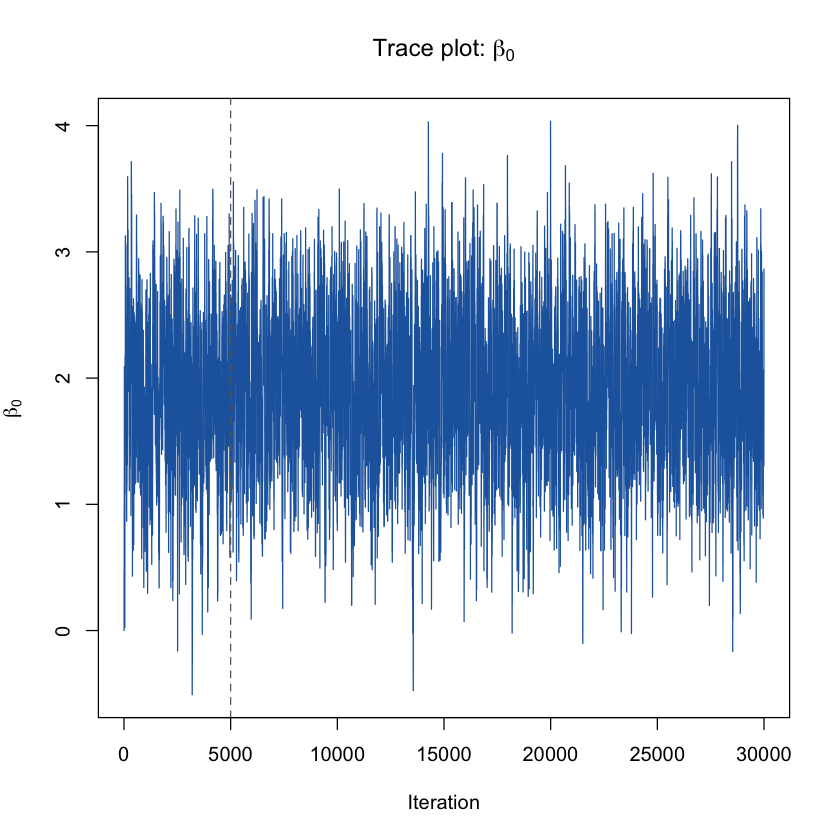

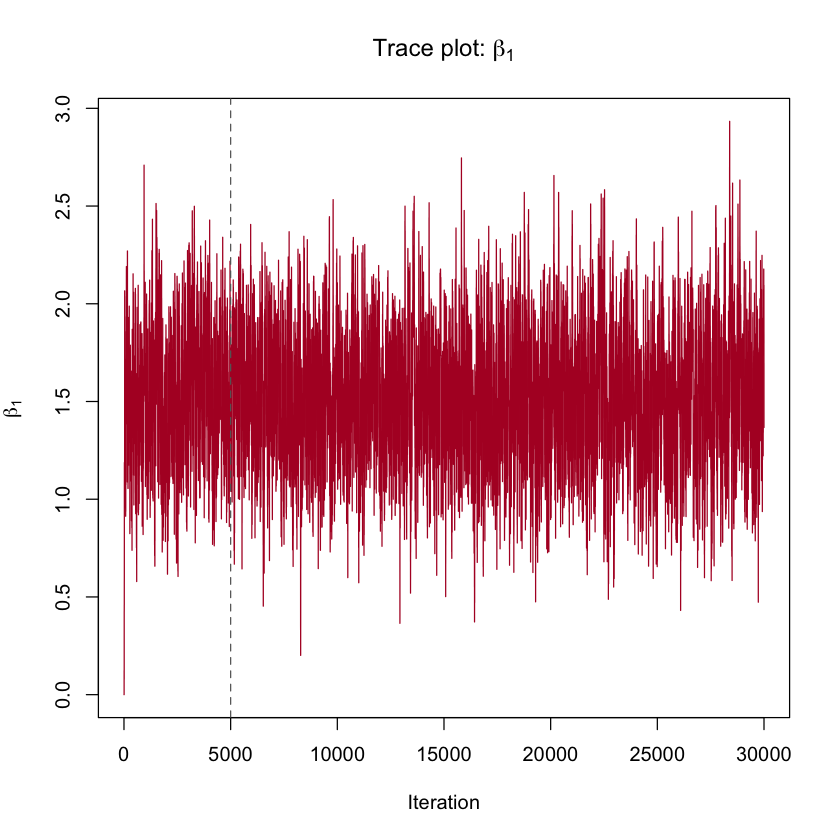

In [5]:
plot(chain[, 1], type = "l", col = "#2166AC", xlab = "Iteration", ylab = expression(beta[0]),
     main = expression(paste("Trace plot: ", beta[0])))
abline(v = burn_in, col = "grey40", lty = 2)
plot(chain[, 2], type = "l", col = "#B2182B", xlab = "Iteration", ylab = expression(beta[1]),
     main = expression(paste("Trace plot: ", beta[1])))
abline(v = burn_in, col = "grey40", lty = 2)


The chain jumps around a stable band immediately (this particular problem is easy — real models often need a longer burn-in), and the dashed line marks where we discarded the initial samples before the chain had settled. Overlaying the raw MCMC samples on the exact posterior contours makes the agreement visual rather than just numerical.


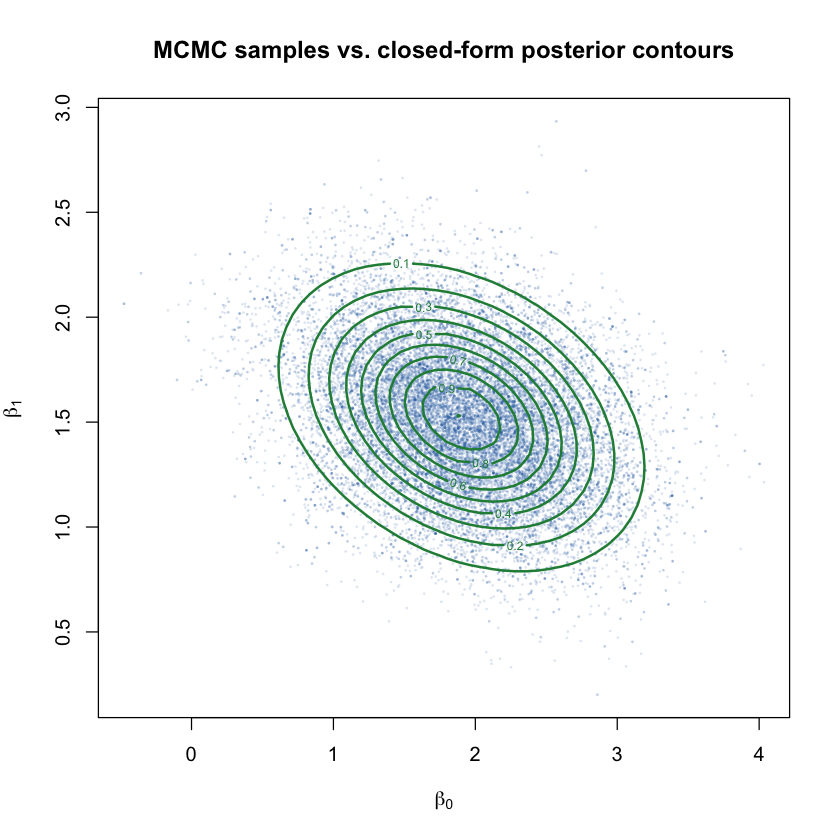

In [6]:
plot(post_burn[, 1], post_burn[, 2], pch = 16, cex = 0.3, col = rgb(0.13, 0.4, 0.67, 0.15),
     xlab = expression(beta[0]), ylab = expression(beta[1]),
     main = "MCMC samples vs. closed-form posterior contours")
contour(b0_seq, b1_seq, Post, nlevels = 8, col = "#238B45", lwd = 2, add = TRUE)


The cloud of blue dots (MCMC samples) sits squarely inside the green contours (the exact posterior) — two completely different computational strategies landing on the same answer.



# What Happens as You Collect More Data

> **Does the prior matter forever, or does it fade?**
> It fades, and it fades at a predictable rate: the influence of the prior is proportional to $1/n$ relative to the data, so as $n$ grows, the likelihood eventually dominates regardless of what prior you started with (as long as the prior didn't rule out the true value entirely).

We can watch this directly by refitting the same conjugate model at increasing sample sizes, keeping the same prior throughout.


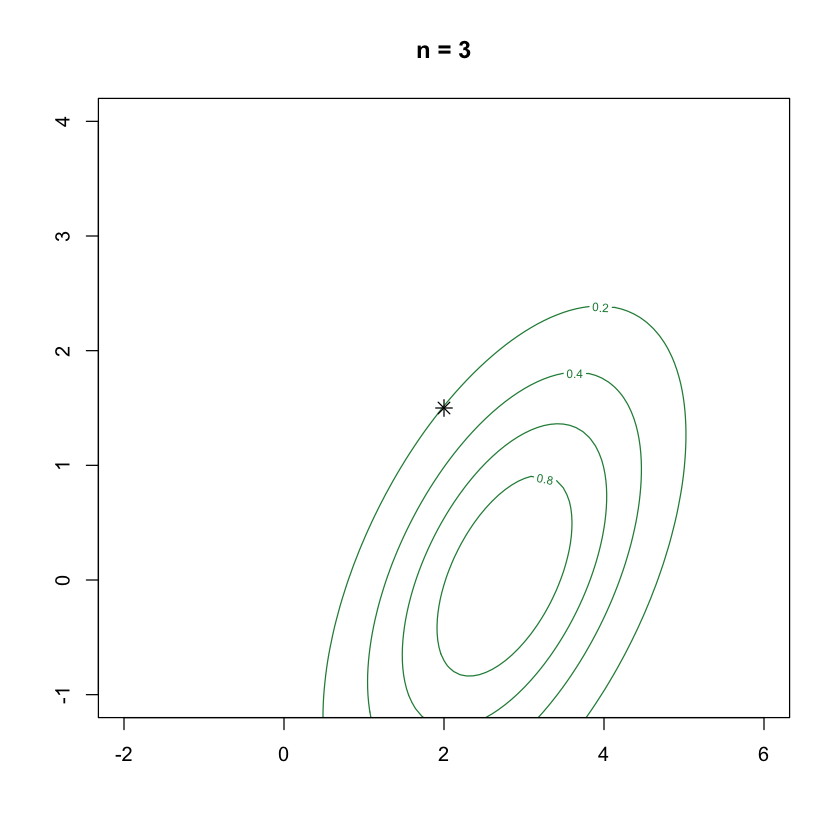

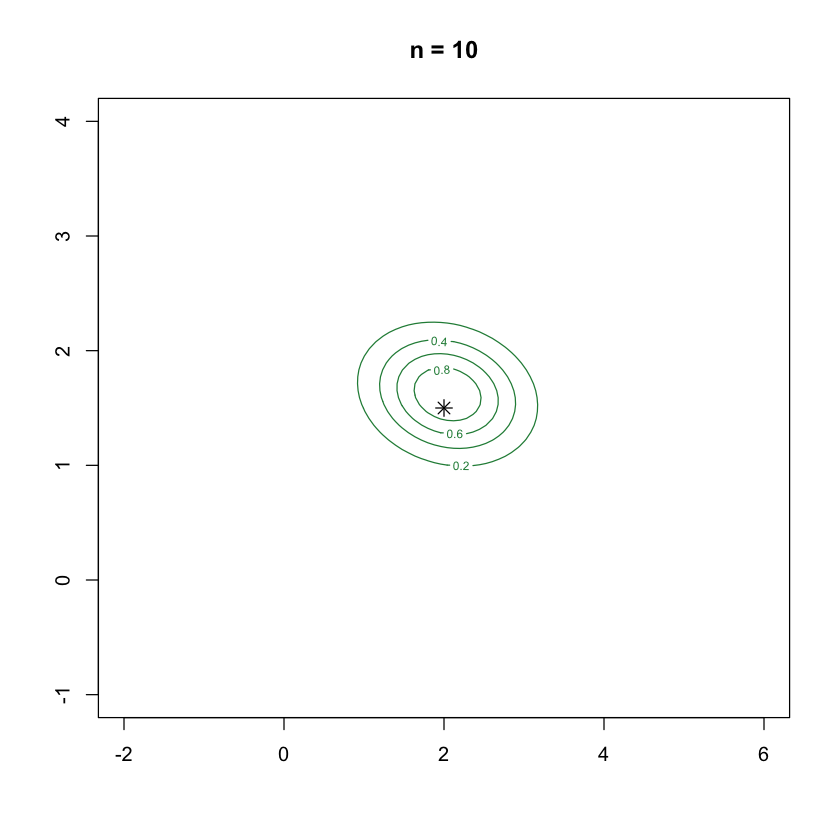

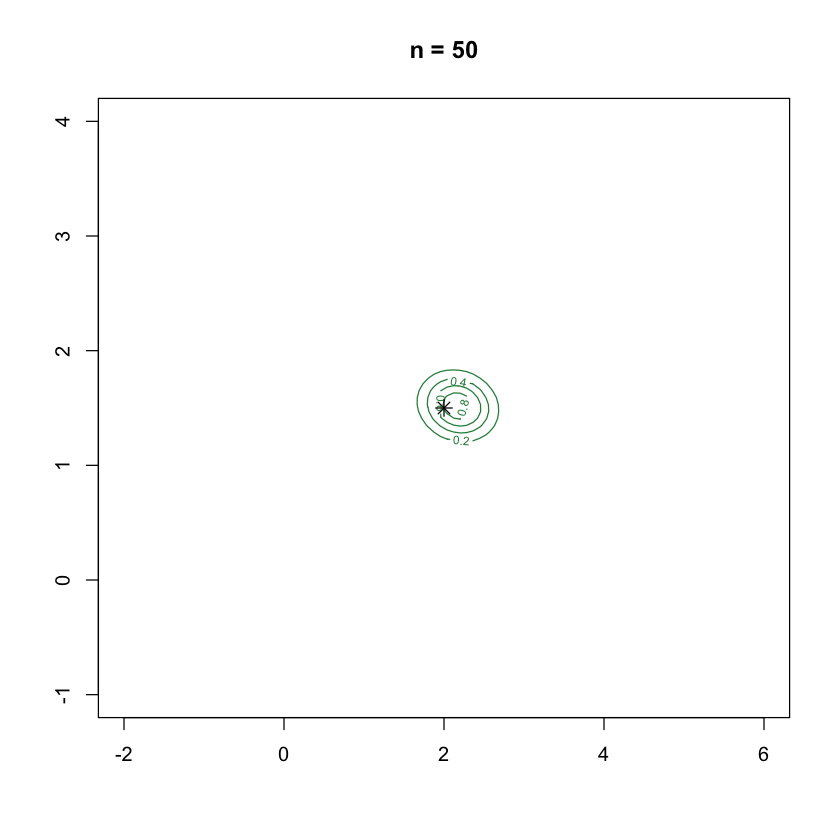

Posterior means as n grows:
n = 3 :  2.756 0.038 
n = 10 :  2.045 1.621 
n = 50 :  2.175 1.519 
n = 500 :  1.93 1.472 


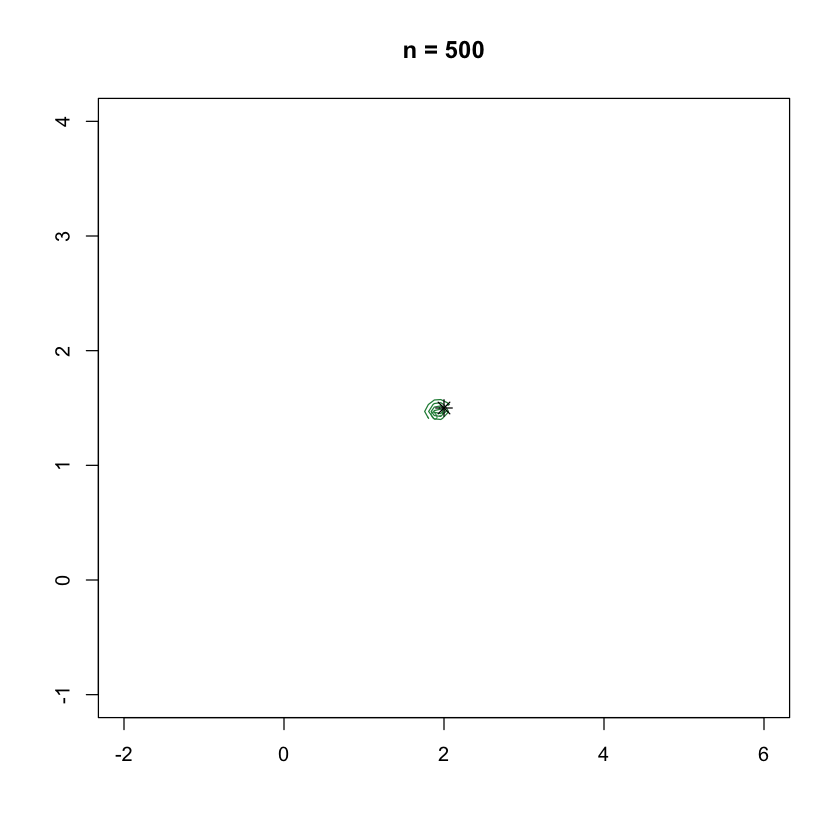

In [7]:
posterior_for_n <- function(n_obs, seed = 1) {
  set.seed(seed)
  x_n <- runif(n_obs, -3, 3)
  y_n <- true_beta0 + true_beta1 * x_n + rnorm(n_obs, sd = sigma)
  X_n <- cbind(1, x_n)
  Sigma_post_n <- solve(solve(Sigma0) + t(X_n) %*% X_n / sigma^2)
  mu_post_n <- Sigma_post_n %*% (solve(Sigma0, mu0) + t(X_n) %*% y_n / sigma^2)
  list(mu = mu_post_n, Sigma = Sigma_post_n)
}

ns <- c(3, 10, 50, 500)
results <- lapply(ns, posterior_for_n)

dmvnorm_diagfree <- function(b0, b1, mu, Sigma) {
  d <- c(b0, b1) - mu
  Sinv <- solve(Sigma)
  exp(-0.5 * t(d) %*% Sinv %*% d)
}

for (i in seq_along(ns)) {
  Post_i <- outer(b0_seq, b1_seq, Vectorize(function(b0, b1)
    dmvnorm_diagfree(b0, b1, results[[i]]$mu, results[[i]]$Sigma)))
  contour(b0_seq, b1_seq, Post_i, nlevels = 6, col = "#238B45",
          main = paste0("n = ", ns[i]), xlim = c(-2, 6), ylim = c(-1, 4))
  points(true_beta0, true_beta1, pch = 8, cex = 1.3)
}

cat("Posterior means as n grows:\n")
for (i in seq_along(ns)) cat("n =", ns[i], ": ", round(results[[i]]$mu, 3), "\n")


With only 3 data points, the posterior is wide and its center ($\beta_1\approx0.04$) is nowhere near the truth (1.5) — there simply isn't enough information yet to overcome the prior's pull toward zero. By $n=500$, the contour has shrunk to a tight cluster right on top of the true value ($\star$), and the specific prior we chose has essentially no influence left.



# What Happens With a Stronger or Weaker Prior

The flip side: at a *fixed* sample size, how much the prior matters depends entirely on how confident (narrow) it is.


OLS estimate: 1.97 1.529 
Very informative (sd=0.5) : posterior mean = 0.925 1.214 
Moderate (sd=3) : posterior mean = 1.902 1.524 
Vague (sd=50) : posterior mean = 1.969 1.529 


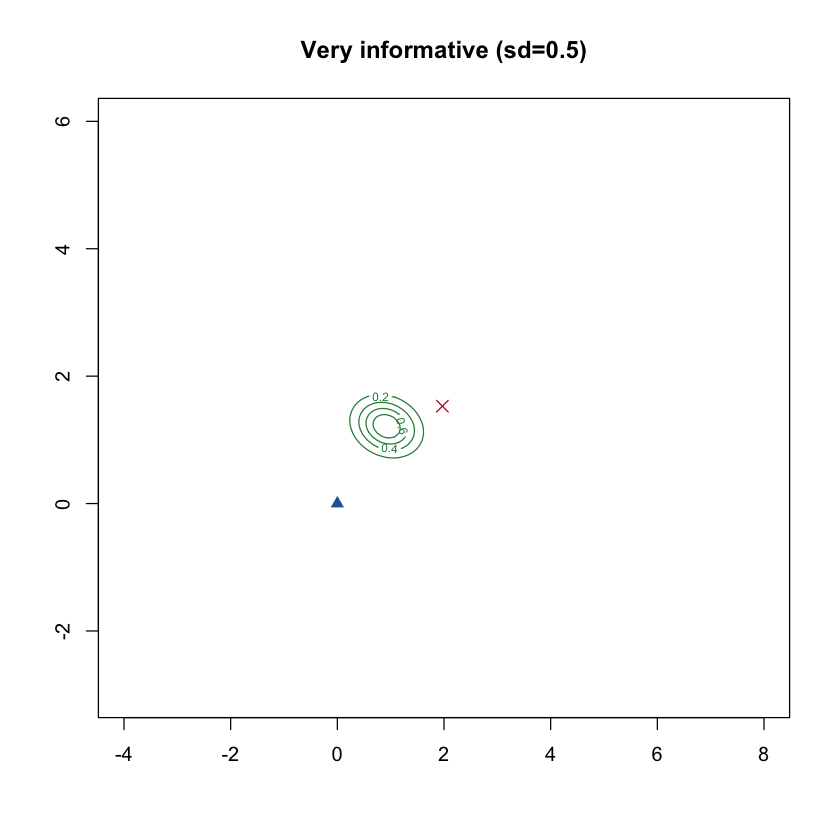

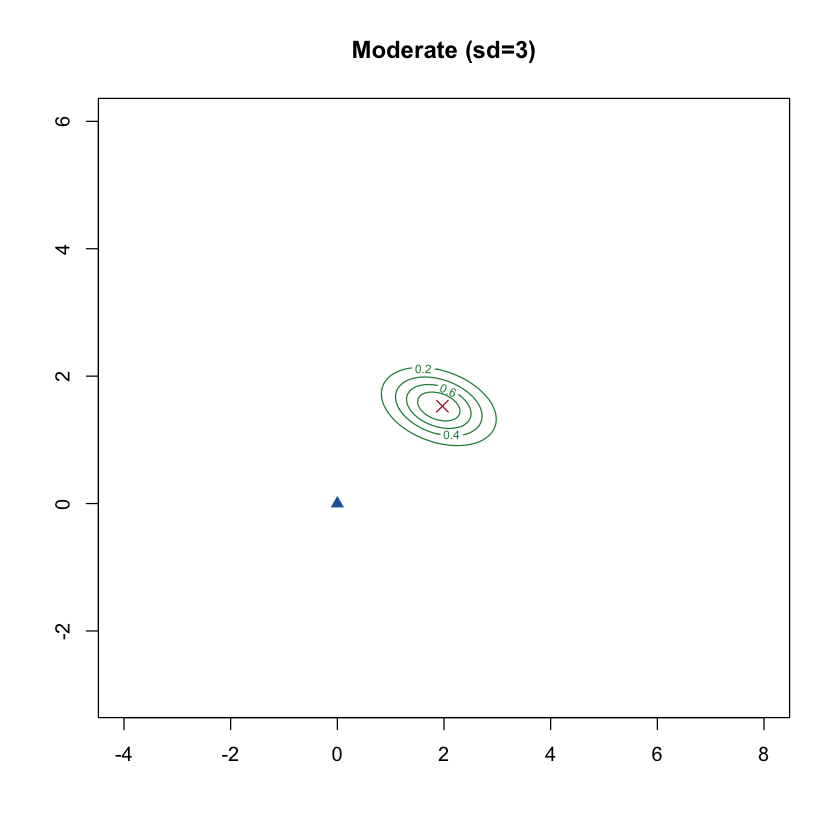

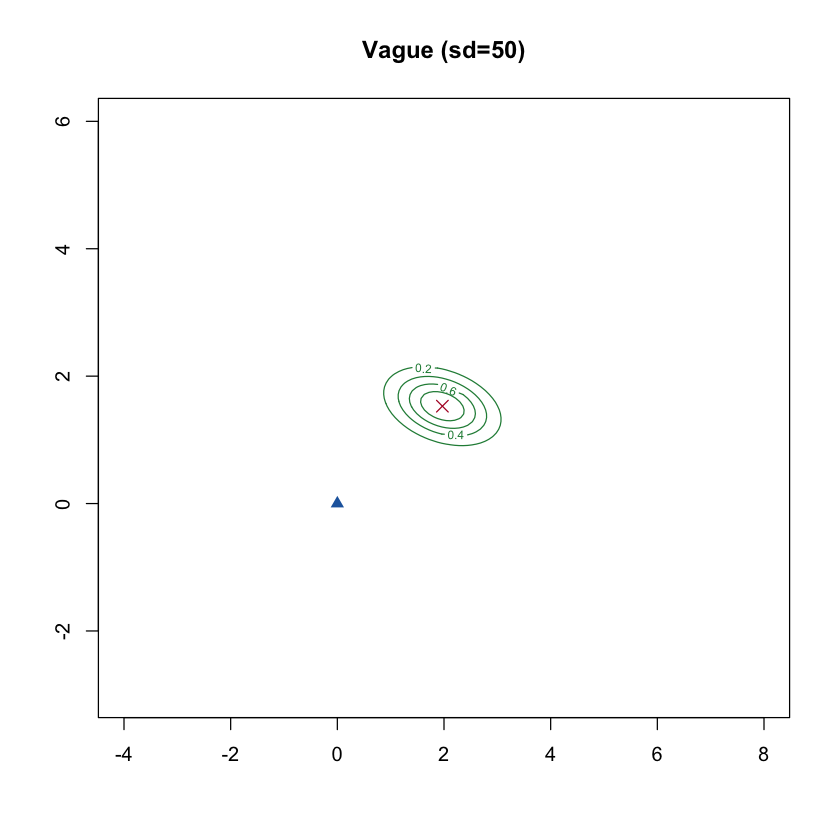

In [8]:
posterior_for_prior <- function(prior_sd_new, prior_mean_new = c(0, 0)) {
  Sigma0_new <- diag(prior_sd_new^2)
  Sigma_post_new <- solve(solve(Sigma0_new) + t(X) %*% X / sigma^2)
  mu_post_new <- Sigma_post_new %*% (solve(Sigma0_new, prior_mean_new) + t(X) %*% y / sigma^2)
  list(mu = mu_post_new, Sigma = Sigma_post_new)
}

priors <- list(
  "Very informative (sd=0.5)" = c(0.5, 0.5),
  "Moderate (sd=3)"           = c(3, 3),
  "Vague (sd=50)"             = c(50, 50)
)
prior_results <- lapply(priors, posterior_for_prior)

ols_coefs <- coef(lm(y ~ x))
cat("OLS estimate:", round(ols_coefs, 3), "\n")
for (nm in names(priors)) cat(nm, ": posterior mean =", round(prior_results[[nm]]$mu, 3), "\n")

for (nm in names(priors)) {
  Post_i <- outer(b0_seq, b1_seq, Vectorize(function(b0, b1)
    dmvnorm_diagfree(b0, b1, prior_results[[nm]]$mu, prior_results[[nm]]$Sigma)))
  contour(b0_seq, b1_seq, Post_i, nlevels = 6, col = "#238B45",
          main = nm, xlim = c(-4, 8), ylim = c(-3, 6))
  points(ols_coefs[1], ols_coefs[2], pch = 4, cex = 1.3, col = "#B2182B")
  points(0, 0, pch = 17, cex = 1.1, col = "#2166AC")
}


With a very informative prior (left), the posterior mean (0.925, 1.214) is pulled substantially away from OLS (1.97, 1.529, red X) toward the prior's center at the origin (blue triangle) — the prior is actively fighting the data. With a vague prior (right), the posterior mean (1.969, 1.529) is essentially identical to OLS — a sufficiently uninformative prior lets the data speak almost entirely for itself. This is the concrete meaning of "how strong is your prior": how much it's willing to override what the data alone would say.



# Summarizing Uncertainty: Credible Intervals

> **How is a Bayesian credible interval different from a frequentist confidence interval?**
> A 95% credible interval is a direct statement about the parameter: given this prior and this data, there's a 95% probability the true coefficient lies in this range. A 95% confidence interval makes a different, more roundabout claim: if we repeated this exact sampling procedure many times, 95% of the intervals we'd construct would contain the true value — it says nothing about the probability for *this specific* interval. In practice, with a weak prior, the two intervals are often numerically close, but the interpretations are genuinely different.

Because our posterior is exactly Normal, the marginal credible intervals have a closed form too.


Bayesian 95% credible interval for beta0: 0.726 3.078 
Frequentist 95% CI for beta0            : 0.481 3.459 

Bayesian 95% credible interval for beta1: 0.854 2.193 
Frequentist 95% CI for beta1            : 0.691 2.366 


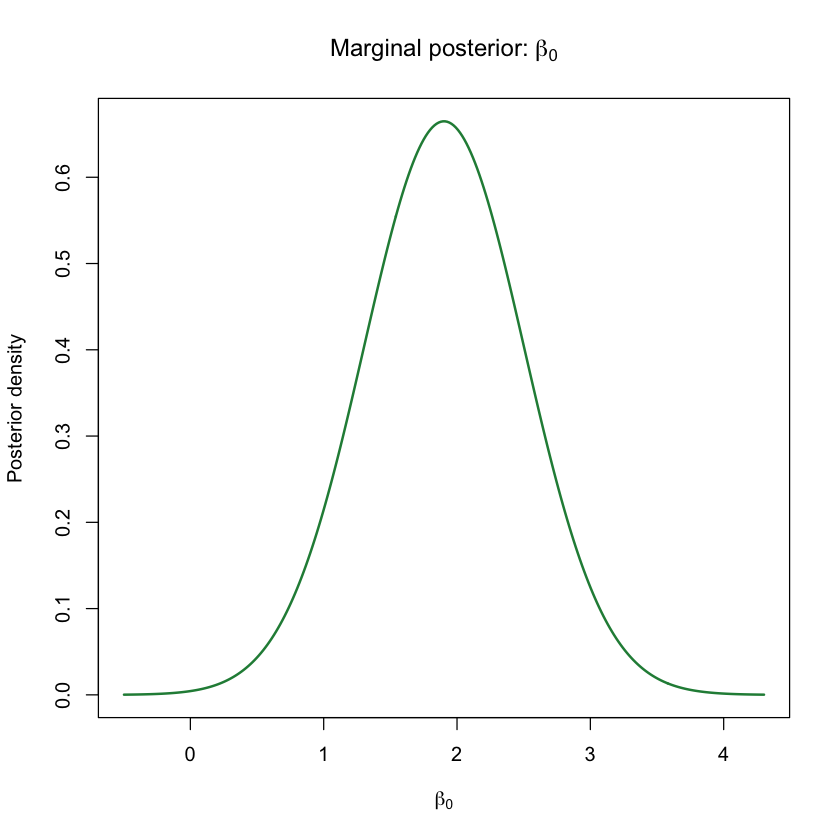

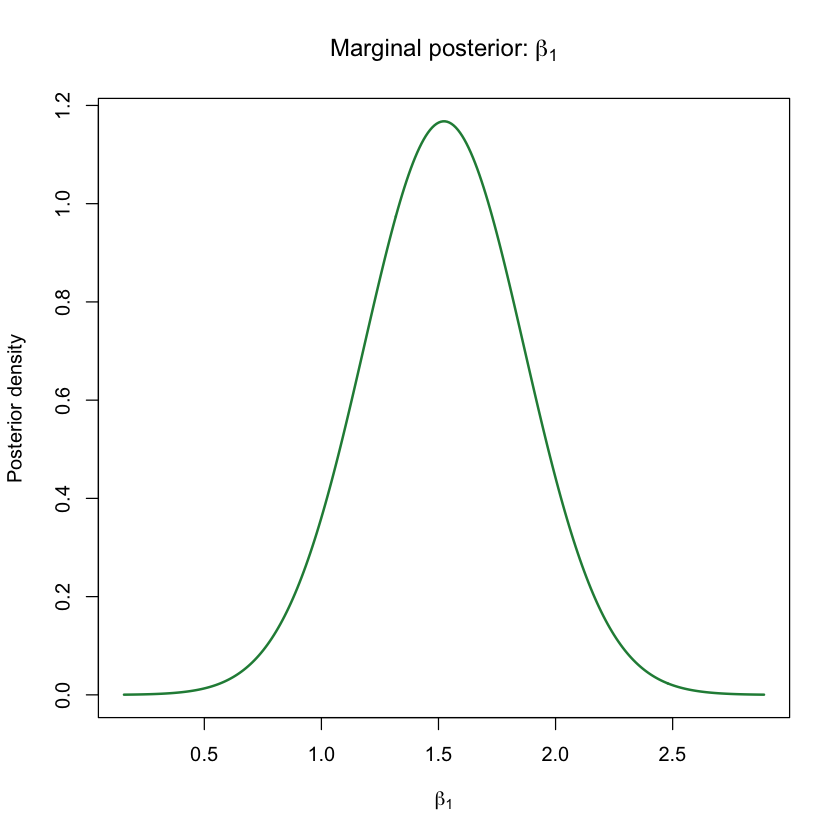

In [9]:
sd_post <- sqrt(diag(Sigma_post))
mu_post_v <- as.vector(mu_post)

## 95% equal-tailed credible intervals (exact, since marginals are Normal)
cred_b0 <- mu_post_v[1] + c(-1, 1) * qnorm(0.975) * sd_post[1]
cred_b1 <- mu_post_v[2] + c(-1, 1) * qnorm(0.975) * sd_post[2]

## Frequentist 95% confidence intervals from OLS
freq_ci <- confint(lm(y ~ x))

cat("Bayesian 95% credible interval for beta0:", round(cred_b0, 3), "\n")
cat("Frequentist 95% CI for beta0            :", round(freq_ci[1, ], 3), "\n\n")
cat("Bayesian 95% credible interval for beta1:", round(cred_b1, 3), "\n")
cat("Frequentist 95% CI for beta1            :", round(freq_ci[2, ], 3), "\n")

b0_range <- seq(mu_post_v[1] - 4 * sd_post[1], mu_post_v[1] + 4 * sd_post[1], length.out = 300)
dens0 <- dnorm(b0_range, mu_post_v[1], sd_post[1])
plot(b0_range, dens0, type = "l", lwd = 2, col = "#238B45",
     xlab = expression(beta[0]), ylab = "Posterior density", main = expression(paste("Marginal posterior: ", beta[0])))

b1_range <- seq(mu_post_v[2] - 4 * sd_post[2], mu_post_v[2] + 4 * sd_post[2], length.out = 300)
dens1 <- dnorm(b1_range, mu_post_v[2], sd_post[2])
plot(b1_range, dens1, type = "l", lwd = 2, col = "#238B45",
     xlab = expression(beta[1]), ylab = "Posterior density", main = expression(paste("Marginal posterior: ", beta[1])))


Here the credible intervals are somewhat narrower than the frequentist ones, because our moderately informative prior is contributing genuine (if modest) extra information beyond what these 12 data points alone provide. The shaded region marks the credible interval; the dashed line marks the true value, which both intervals correctly capture in this example.



# The Posterior Predictive Distribution

The posterior over $(\beta_0,\beta_1)$ answers "what do we believe about the coefficients." A different, often more directly useful question is: "what do we believe about a *new* $y$ value at a given $x$?" This is the **posterior predictive distribution**, and it has to account for two separate sources of uncertainty:

$$
\text{Var}(y_{\text{new}} \mid x_{\text{new}}, y) = \underbrace{x_{\text{new}}^\top \Sigma_{\text{post}}\, x_{\text{new}}}_{\text{uncertainty about the line itself}} + \underbrace{\sigma^2}_{\text{irreducible observation noise}}
$$

Even if we knew $\beta_0,\beta_1$ perfectly, individual points would still scatter around the line by $\sigma$; the posterior predictive interval has to be at least that wide everywhere, and gets wider still near the edges of the data, where we're less sure exactly where the line sits.


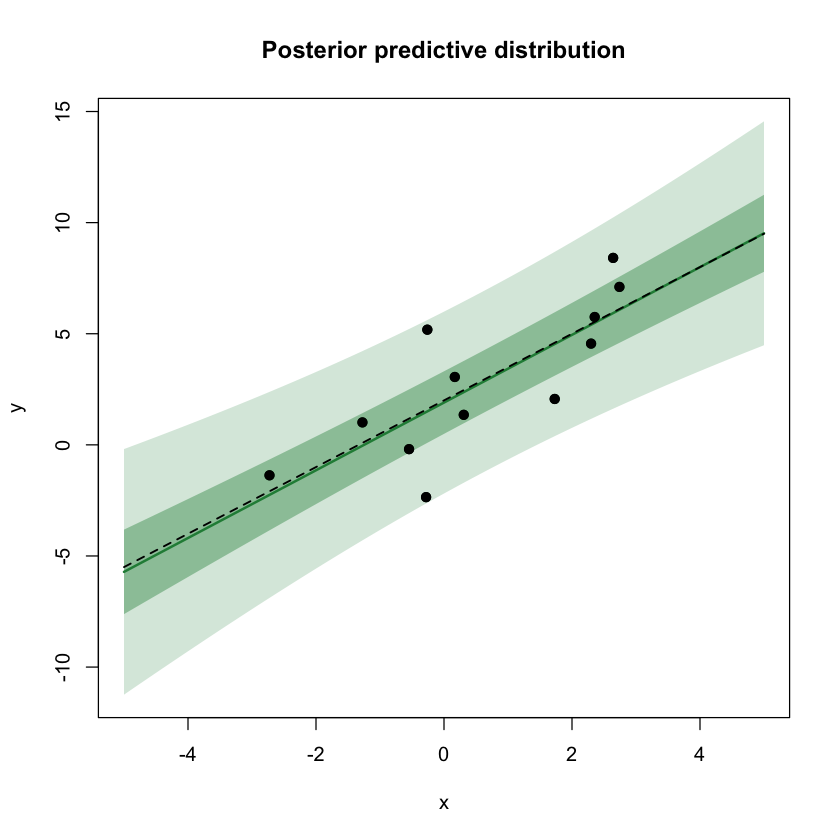

In [10]:
x_new <- seq(-5, 5, length.out = 100)

pred_mean <- as.vector(mu_post_v[1] + mu_post_v[2] * x_new)
pred_sd <- sqrt(sapply(x_new, function(xn) {
  xv <- c(1, xn)
  as.numeric(t(xv) %*% Sigma_post %*% xv) + sigma^2
}))

lower95 <- pred_mean - qnorm(0.975) * pred_sd
upper95 <- pred_mean + qnorm(0.975) * pred_sd
lower50 <- pred_mean - qnorm(0.75) * pred_sd
upper50 <- pred_mean + qnorm(0.75) * pred_sd

plot(x, y, pch = 19, xlim = range(x_new), ylim = range(c(lower95, upper95, y)),
     xlab = "x", ylab = "y", main = "Posterior predictive distribution")
polygon(c(x_new, rev(x_new)), c(lower95, rev(upper95)), col = rgb(0.14, 0.55, 0.27, 0.2), border = NA)
polygon(c(x_new, rev(x_new)), c(lower50, rev(upper50)), col = rgb(0.14, 0.55, 0.27, 0.4), border = NA)
lines(x_new, pred_mean, col = "#238B45", lwd = 2)
lines(x_new, true_beta0 + true_beta1 * x_new, col = "black", lty = 2, lwd = 1.5)
points(x, y, pch = 19)


The band is narrowest near the middle of the observed $x$ values (where the data constrains the line best) and flares out toward the edges — exactly the intuition that predictions get less certain the further you extrapolate. Even at the very center, though, the band never collapses to a thin line, because $\sigma$ (the irreducible noise) sets a floor on how tight any prediction interval can be.



# Summary

1. Bayesian regression treats coefficients as uncertain quantities with a probability distribution, rather than fixed numbers with a single best estimate.
2. The posterior is just the prior and the likelihood multiplied together: $P(\beta\mid y) \propto P(y\mid\beta)\,P(\beta)$.
3. When the prior and likelihood are both Normal, the posterior is Normal too, with an exact closed-form mean and covariance — a weighted average between what the prior believed and what the data alone would say.
4. When there's no closed form (the usual case in practice), Markov chain Monte Carlo methods like Metropolis-Hastings let you sample from the posterior instead of computing it directly, and — as shown here — they agree with the exact answer when one is available.
5. More data shrinks the posterior and reduces the prior's influence; a more informative (narrower) prior increases that influence at any fixed amount of data.
6. Credible intervals and confidence intervals often look numerically similar, but answer genuinely different questions.
7. The posterior *predictive* distribution folds in an extra source of uncertainty — the residual noise $\sigma^2$ — on top of the parameter uncertainty in the posterior itself.

This same machinery — priors over effect sizes, exact or sampled posteriors, and shrinkage toward the prior — is the foundation behind Bayesian polygenic score methods like SBayesR, just scaled up to millions of genetic variants instead of two coefficients.



# References

- Lindley, D. V. & Smith, A. F. M. (1972). Bayes estimates for the linear model. *Journal of the Royal Statistical Society: Series B*, 34, 1–41.
- Metropolis, N., Rosenbluth, A. W., Rosenbluth, M. N., Teller, A. H. & Teller, E. (1953). Equation of state calculations by fast computing machines. *Journal of Chemical Physics*, 21, 1087–1092.
- Hastings, W. K. (1970). Monte Carlo sampling methods using Markov chains and their applications. *Biometrika*, 57, 97–109.
- Gelman, A., Carlin, J. B., Stern, H. S., Dunson, D. B., Vehtari, A. & Rubin, D. B. (2013). *Bayesian Data Analysis* (3rd ed.). CRC Press.
- Kruschke, J. K. (2015). *Doing Bayesian Data Analysis* (2nd ed.). Academic Press.
